In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / 'pyproject.toml').is_file()
)
DATASET_PATH = PROJECT_ROOT / 'dataset' / 'pima_indians_diabetes.csv'
MODEL_DIR = PROJECT_ROOT / 'out' / 'models'

In [2]:
# 1. Load Dataset
df = pd.read_csv(DATASET_PATH)

# 2. Inspect Dataset Structure
print("--- Dataset Shape ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")

print("--- First 5 Rows ---")
display(df.head())

print("--- Dataset Information ---")
print(df.info())

print("\n--- Check for Duplicate Rows ---")
duplicates = df.duplicated().sum()
print(f"Duplicate records found: {duplicates}")

print("\n--- Summary Statistics ---")
display(df.describe().T)

--- Dataset Shape ---
Rows: 768, Columns: 9

--- First 5 Rows ---


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

--- Check for Duplicate Rows ---
Duplicate records found: 0

--- Summary Statistics ---


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [3]:
# List of physiological columns where 0 indicates a missing value
zero_invalid_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Count invalid zeros per column
print("--- Zero Count Before Imputation ---")
zero_counts = (df[zero_invalid_cols] == 0).sum()
print(zero_counts)

# These zeros are imputed later using training data only

--- Zero Count Before Imputation ---
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [4]:
from sklearn.model_selection import train_test_split

# 1. Target Class Breakdown
print("--- Target Class Breakdown ---")
class_counts = df['Outcome'].value_counts()
class_props = df['Outcome'].value_counts(normalize=True) * 100
print(pd.DataFrame({'Count': class_counts, 'Percentage (%)': class_props.round(2)}))

# 2. Separate Features (X) and Target (y)
X = df.drop(columns=['Outcome'])
y = df['Outcome']

# 3. Stratified Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"\nTraining Set Shape: {X_train.shape}")
print(f"Testing Set Shape:  {X_test.shape}")

--- Target Class Breakdown ---
         Count  Percentage (%)
Outcome                       
0          500            65.1
1          268            34.9



Training Set Shape: (614, 8)
Testing Set Shape:  (154, 8)


In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Learn imputation and scaling values from training data only
preprocessor = Pipeline([
    ('zero_imputer', ColumnTransformer(
        transformers=[
            ('invalid_zero_imputer', SimpleImputer(missing_values=0, strategy='median'), zero_invalid_cols),
        ],
        remainder='passthrough',
        verbose_feature_names_out=False,
    )),
    ('scaler', StandardScaler()),
])
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

# Convert back to DataFrame for clean readability
scaled_feature_names = preprocessor.named_steps['zero_imputer'].get_feature_names_out()
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=scaled_feature_names)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=scaled_feature_names)

print("--- Scaled Training Features Sample (First 3 Rows) ---")
display(X_train_scaled_df.head(3))

--- Scaled Training Features Sample (First 3 Rows) ---


,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Pregnancies,DiabetesPedigreeFunction,Age
0,-1.056427,-0.826740,-1.918187,-1.203361,-0.769694,-0.851355,0.310794,-0.792169
1,0.144399,0.477772,-0.229874,-1.470195,-0.417714,0.356576,-0.116439,0.561034
2,-0.556083,-1.152868,1.233330,-0.555335,0.359576,-0.549372,-0.764862,-0.707594


In [6]:
class KNNFromScratch:
    def __init__(self, k=5):
        self.k = k

    def fit(self, X, y):
        # Store training features and labels
        self.X_train = np.array(X)
        self.y_train = np.array(y)

    def _euclidean_distance(self, x1, x2):
        # Compute Euclidean distance: sqrt(sum((x1 - x2)^2))
        return np.sqrt(np.sum((x1 - x2) ** 2))

    def predict(self, X_test):
        X_test = np.array(X_test)
        predictions = [self._predict_single(x) for x in X_test]
        return np.array(predictions)

    def _predict_single(self, x):
        # 1. Compute distances between test point 'x' and all training points
        distances = [self._euclidean_distance(x, x_train_point) for x_train_point in self.X_train]
        
        # 2. Get indices of the k nearest neighbors
        k_indices = np.argsort(distances)[:self.k]
        
        # 3. Extract the labels of the k nearest neighbors
        k_nearest_labels = [self.y_train[i] for i in k_indices]
        
        # 4. Majority vote to decide predicted class
        most_common = np.bincount(k_nearest_labels).argmax()
        return most_common

    def predict_proba(self, X_test):
        # Predict class probabilities (proportion of k neighbors belonging to class 1)
        X_test = np.array(X_test)
        probs = []
        for x in X_test:
            distances = [self._euclidean_distance(x, x_train_point) for x_train_point in self.X_train]
            k_indices = np.argsort(distances)[:self.k]
            k_nearest_labels = [self.y_train[i] for i in k_indices]
            prob_class_1 = np.sum(k_nearest_labels) / self.k
            probs.append([1 - prob_class_1, prob_class_1])
        return np.array(probs)

# --- Train & Predict with Custom KNN ---
knn_custom = KNNFromScratch(k=7)
knn_custom.fit(X_train_scaled, y_train)

# Generate predictions on test set
knn_preds = knn_custom.predict(X_test_scaled)
knn_probs = knn_custom.predict_proba(X_test_scaled)[:, 1]

print("KNN (From Scratch) trained and predictions generated successfully!")
print(f"First 10 Predictions: {knn_preds[:10]}")

KNN (From Scratch) trained and predictions generated successfully!
First 10 Predictions: [1 0 0 0 0 0 0 1 0 1]


In [7]:
from sklearn.tree import DecisionTreeClassifier

# 1. Initialize Decision Tree with Pruning (Overfitting Control)
dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=4,            # Pruning depth to avoid memorizing noise
    min_samples_split=10,   # Minimum samples required to split an internal node
    random_state=42
)

# 2. Train on scaled training data
dt_model.fit(X_train_scaled, y_train)

# 3. Predict on test data
dt_preds = dt_model.predict(X_test_scaled)
dt_probs = dt_model.predict_proba(X_test_scaled)[:, 1]

print("Decision Tree Trained Successfully!")
print(f"First 10 Predictions: {dt_preds[:10]}")

Decision Tree Trained Successfully!
First 10 Predictions: [1 0 0 1 0 0 0 1 0 1]


In [8]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.svm import SVC

# 1. Initialize and calibrate the SVM for probability estimates
svm_base_model = SVC(
    kernel='rbf',          # Radial Basis Function kernel for non-linear boundaries
    C=1.0,                 # Regularization parameter
    gamma='scale',         # Kernel coefficient
    random_state=42
)
svm_model = CalibratedClassifierCV(
    estimator=svm_base_model, method='sigmoid', cv=5, ensemble=False
)

# 2. Train on scaled training data
svm_model.fit(X_train_scaled, y_train)

# 3. Predict on test data
svm_preds = svm_model.predict(X_test_scaled)
svm_probs = svm_model.predict_proba(X_test_scaled)[:, 1]

print("Support Vector Machine (SVM) Trained Successfully!")
print(f"First 10 Predictions: {svm_preds[:10]}")

Support Vector Machine (SVM) Trained Successfully!
First 10 Predictions: [1 0 0 0 0 0 0 1 0 1]


In [9]:
from sklearn.naive_bayes import GaussianNB

# 1. Initialize Gaussian Naive Bayes Model
nb_model = GaussianNB()

# 2. Train on scaled training data
nb_model.fit(X_train_scaled, y_train)

# 3. Predict on test data
nb_preds = nb_model.predict(X_test_scaled)
nb_probs = nb_model.predict_proba(X_test_scaled)[:, 1]

print("Gaussian Naïve Bayes Trained Successfully!")
print(f"First 10 Predictions: {nb_preds[:10]}")

Gaussian Naïve Bayes Trained Successfully!
First 10 Predictions: [1 0 0 0 0 0 1 1 0 1]


In [10]:
from sklearn.neural_network import MLPClassifier

# 1. Initialize Multi-Layer Perceptron (Neural Network)
mlp_model = MLPClassifier(
    hidden_layer_sizes=(16, 8),   # Two hidden layers with 16 and 8 neurons
    activation='relu',            # ReLU activation function
    solver='adam',                # Optimizer
    alpha=0.01,                   # L2 regularization penalty to prevent overfitting
    max_iter=1000,                # Maximum training epochs
    random_state=42
)

# 2. Train on scaled training data
mlp_model.fit(X_train_scaled, y_train)

# 3. Predict on test data
mlp_preds = mlp_model.predict(X_test_scaled)
mlp_probs = mlp_model.predict_proba(X_test_scaled)[:, 1]

print("Multi-Layer Perceptron (MLP) Trained Successfully!")
print(f"First 10 Predictions: {mlp_preds[:10]}")

Multi-Layer Perceptron (MLP) Trained Successfully!
First 10 Predictions: [1 0 0 0 0 0 0 1 0 1]


--- MODEL PERFORMANCE METRICS TABLE ---


,Accuracy,Precision,Recall (Sensitivity),Specificity,F1-Score,ROC-AUC,MCC
Custom KNN,0.7273,0.6250,0.5556,0.82,0.5882,0.7900,0.3869
Decision Tree,0.7857,0.6981,0.6852,0.84,0.6916,0.7887,0.5275
Support Vector Machine,0.7403,0.6522,0.5556,0.84,0.6000,0.7963,0.4124
Gaussian Naïve Bayes,0.7013,0.5667,0.6296,0.74,0.5965,0.7646,0.3617
Multi-Layer Perceptron,0.7273,0.6154,0.5926,0.80,0.6038,0.8104,0.3961


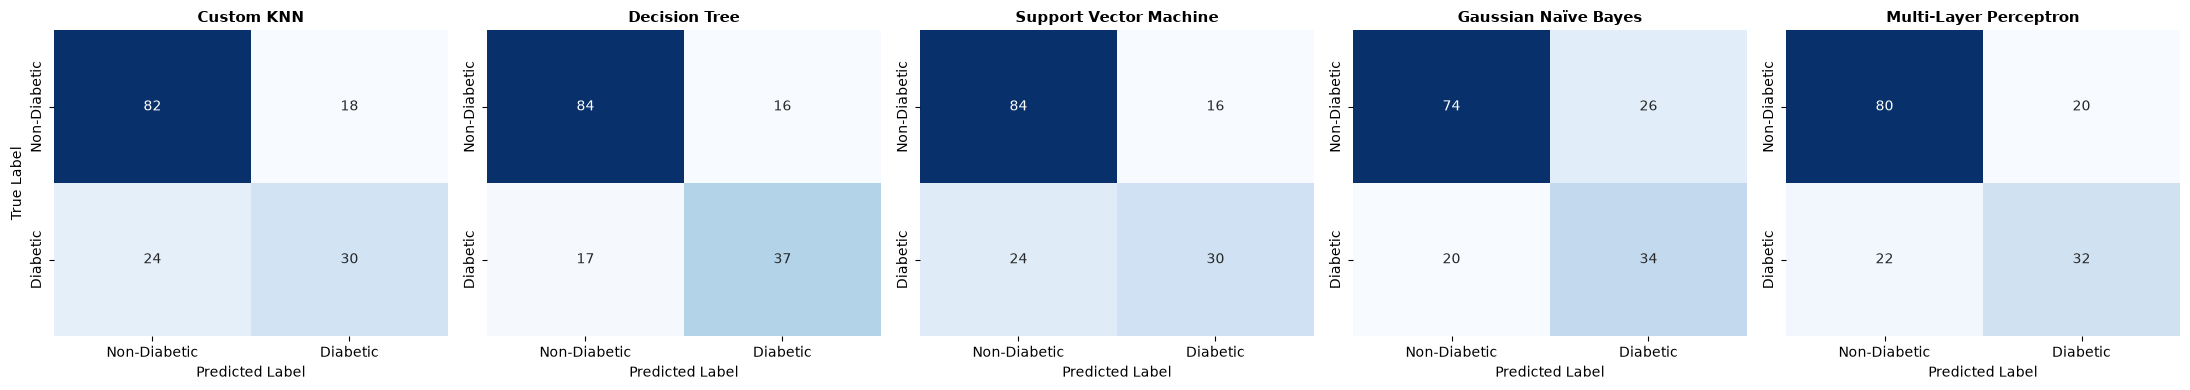

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score, 
    f1_score, roc_auc_score, matthews_corrcoef
)

# 1. Dictionary storing predictions and probabilities for all 5 models
models_eval = {
    'Custom KNN': (knn_preds, knn_probs),
    'Decision Tree': (dt_preds, dt_probs),
    'Support Vector Machine': (svm_preds, svm_probs),
    'Gaussian Naïve Bayes': (nb_preds, nb_probs),
    'Multi-Layer Perceptron': (mlp_preds, mlp_probs)
}

# 2. Function to compute required and additional metrics
def calculate_metrics(y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    # Additional Justified Metrics
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    auc = roc_auc_score(y_true, y_prob)
    mcc = matthews_corrcoef(y_true, y_pred)
    
    return {
        'Accuracy': acc,
        'Precision': prec,
        'Recall (Sensitivity)': rec,
        'Specificity': spec,
        'F1-Score': f1,
        'ROC-AUC': auc,
        'MCC': mcc
    }

# 3. Calculate metrics for all models
metrics_results = {}
for name, (preds, probs) in models_eval.items():
    metrics_results[name] = calculate_metrics(y_test, preds, probs)

# Convert to DataFrame
df_metrics = pd.DataFrame(metrics_results).T
print("--- MODEL PERFORMANCE METRICS TABLE ---")
display(df_metrics.round(4))

# 4. Plot Confusion Matrices
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
model_names = list(models_eval.keys())

for i, name in enumerate(model_names):
    preds = models_eval[name][0]
    cm = confusion_matrix(y_test, preds)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[i],
                xticklabels=['Non-Diabetic', 'Diabetic'],
                yticklabels=['Non-Diabetic', 'Diabetic'])
    axes[i].set_title(f"{name}", fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Predicted Label')
    if i == 0:
        axes[i].set_ylabel('True Label')

plt.tight_layout()
plt.show()

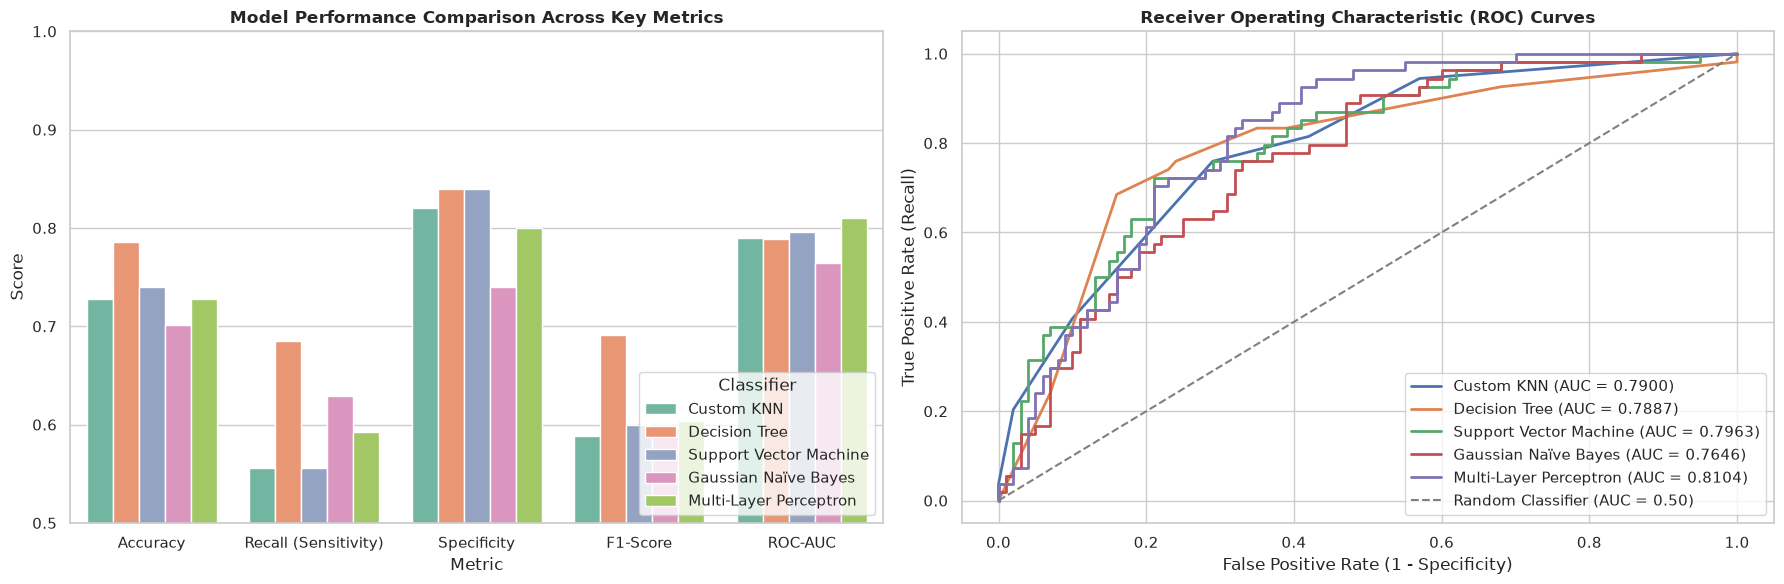

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve

# Set style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 1. Bar Plot Comparison of Metrics
df_metrics_plot = df_metrics[['Accuracy', 'Recall (Sensitivity)', 'Specificity', 'F1-Score', 'ROC-AUC']].reset_index()
df_melted = df_metrics_plot.melt(id_vars='index', var_name='Metric', value_name='Score')

sns.barplot(data=df_melted, x='Metric', y='Score', hue='index', ax=axes[0], palette='Set2')
axes[0].set_title('Model Performance Comparison Across Key Metrics', fontsize=12, fontweight='bold')
axes[0].set_ylim(0.5, 1.0)
axes[0].legend(title='Classifier', loc='lower right')
axes[0].set_ylabel('Score')

# 2. Multi-Model ROC Curve Plot
for name, (preds, probs) in models_eval.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_val = df_metrics.loc[name, 'ROC-AUC']
    axes[1].plot(fpr, tpr, lw=2, label=f'{name} (AUC = {auc_val:.4f})')

axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5, label='Random Classifier (AUC = 0.50)')
axes[1].set_title('Receiver Operating Characteristic (ROC) Curves', fontsize=12, fontweight='bold')
axes[1].set_xlabel('False Positive Rate (1 - Specificity)')
axes[1].set_ylabel('True Positive Rate (Recall)')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

In [13]:
import joblib
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Save the exact preprocessing and MLP used during evaluation as one artifact
diabetes_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', mlp_model),
])
pipeline_path = MODEL_DIR / 'diabetes_pipeline.joblib'
joblib.dump(diabetes_pipeline, pipeline_path)

print(f"Deployment pipeline saved to {pipeline_path}")

Deployment pipeline saved to /home/jrtilak/coding/jrtilak/Diabetes-Classifier-Data-Mining/out/models/diabetes_pipeline.joblib
